Hello, I have chosen two animals to classify their genetic sequences: Pinicola (Pine finch) and Haemorhous mexicanus (House finch). These two animals are from the family Fringillidae and the subfamily Carduelinae.

I took the datasets of the nucleotide sequences of these organisms from the website 
 https://www.ncbi.nlm.nih.gov/                     

Haemorhous mexicanus : https://www.ncbi.nlm.nih.gov/nuccore/?term=Haemorhous+mexicanus

Pinicola : https://www.ncbi.nlm.nih.gov/nuccore/?term=Pinicola


Dataset Story:

Purpose of the Dataset
This dataset aims to classify genetic sequences of Haemorhous mexicanus and Pinicola species.

Source of the Dataset
Data were obtained from the NCBI GenBank database:

Genetic sequences of both species were sequenced in vitro and stored in FASTA format.

Content of the Dataset
Each record contains a DNA sequence and its class label:
Genetic_Data: DNA sequence (e.g. "ACGTAGCTAGG...").

Class: Species to which the genetic sequence belongs (e.g. "Haemorhous mexicanus" or "Pinicola").

Preparation of the Dataset
Genetic sequences of each species were obtained as separate FASTA files.

Data for Haemorhous mexicanus and Pinicola species were merged.

This data was converted into a DataFrame and made suitable for machine learning models.

Methods Used
n-gram analysis: DNA sequences were analyzed with character-based n-gram methods.

Machine learning models: Algorithms such as Logistic Regression, Random Forest, Naive Bayes were applied for the classification of species.

In [ ]:
pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 28.8 MB/s eta 0:00:00


Model: Logistic Regression
Accuracy: 82.52%

Classification Report:
              precision    recall  f1-score   support

       Live1       0.83      0.98      0.90      9843
       Live2       0.79      0.23      0.36      2626

    accuracy                           0.83     12469
   macro avg       0.81      0.61      0.63     12469
weighted avg       0.82      0.83      0.78     12469

Model: Random Forest
Accuracy: 92.07%

Classification Report:
              precision    recall  f1-score   support

       Live1       0.94      0.96      0.95      9843
       Live2       0.85      0.76      0.80      2626

    accuracy                           0.92     12469
   macro avg       0.89      0.86      0.88     12469
weighted avg       0.92      0.92      0.92     12469

Model: Support Vector Machine
Accuracy: 85.35%

Classification Report:
              precision    recall  f1-score   support

       Live1       0.86      0.98      0.91      9843
       Live2       0.83      0.38   

<ipython-input-4-355f981e4d4c>:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis')


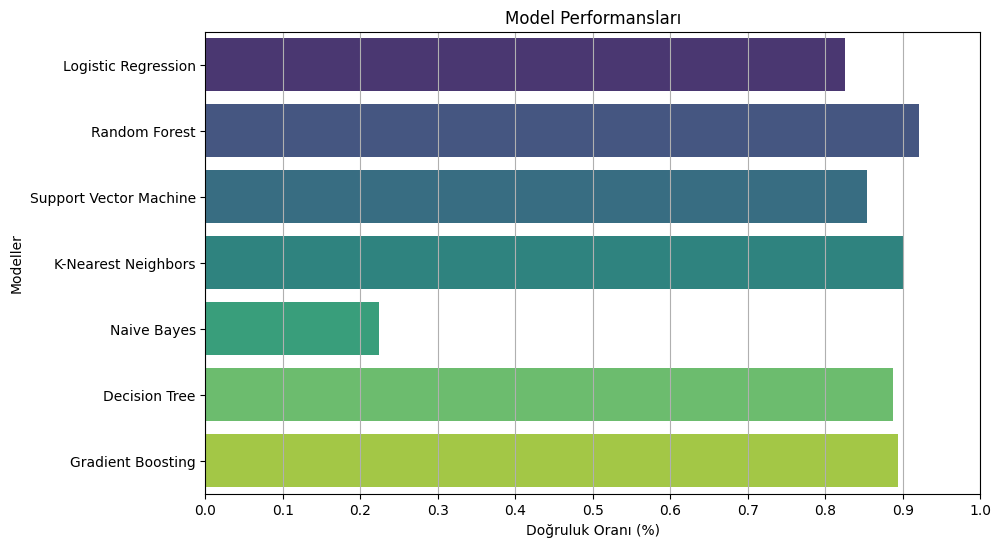


Tüm Modellerin Performansı:
                    Model  Accuracy
0     Logistic Regression  0.825247
1           Random Forest  0.920683
2  Support Vector Machine  0.853477
3     K-Nearest Neighbors  0.900874
4             Naive Bayes  0.224236
5           Decision Tree  0.887641
6       Gradient Boosting  0.893817


In [ ]:
#Veri işleme, biyolojik dizilerle çalışma, makine öğrenimi modelleri ve görselleştirme işlemleri için gerekli kütüphanelerin projeye ekliyoruz
import pandas as pd
from Bio import SeqIO
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# FASTA dosyalarını okumak için fonksiyon
def read_fasta(file_path, label):
    records = []
    for record in SeqIO.parse(file_path, "fasta"):
        records.append({'Genetic_Data': str(record.seq), 'Class': label})
    return records

# Canlı 1 ve Canlı 2 FASTA dosyalarını okuma
live1_records = read_fasta('Pinicola.fasta', 'Live1')
live2_records = read_fasta('Haemorhous-mexicanus.fasta', 'Live2')

# Tüm kayıtları birleştirme ve bir DataFrame oluşturuyoruz
all_records = live1_records + live2_records
df = pd.DataFrame(all_records)

# Veri Ön İşleme
vectorizer = CountVectorizer(analyzer='char', ngram_range=(1, 1))  # Karakter bazlı n-gram
X = vectorizer.fit_transform(df['Genetic_Data'])  # Genetik veriyi dönüştür
y = df['Class']  # Sınıf etiketleri

# Veriyi Eğitim ve Test Setlerine Ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Seyrek veriyi yoğun formata dönüştürme (Naive Bayes için)
X_train_dense = X_train.toarray()
X_test_dense = X_test.toarray()

# Farklı Makine Öğrenmesi Modellerini Eğitme ve Performans Analizi
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(),
    'Support Vector Machine': SVC(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(),
    'Gradient Boosting': GradientBoostingClassifier()
}

results = []

for model_name, model in models.items():
    # Modeli eğitme
    if model_name == 'Naive Bayes':
        model.fit(X_train_dense, y_train)  # Yoğun veri kullan
    else:
        model.fit(X_train, y_train)  # Seyrek veri kullan

    # Test setinde tahmin yapma
    y_pred = model.predict(X_test_dense if model_name == 'Naive Bayes' else X_test)

    # Doğruluk hesaplama
    accuracy = accuracy_score(y_test, y_pred)

    # Sonuçları listeye ekleme
    results.append({'Model': model_name, 'Accuracy': accuracy})

    # Model performansını yazdırma
    print(f"Model: {model_name}")
    print(f"Accuracy: {accuracy * 100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

# Sonuçları DataFrame'e dönüştürme
results_df = pd.DataFrame(results)

#Sonuçların plt kütüphanesi ile görselleştirme
plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis')
plt.title('Model Performansları')
plt.xlabel('Doğruluk Oranı (%)')
plt.ylabel('Modeller')
plt.xlim(0, 1)
plt.xticks([i / 10 for i in range(0, 11)])
plt.grid(axis='x')
plt.show()

# Sonuçların toplu gösterimi
print("\nTüm Modellerin Performansı:")
print(results_df)

Random Forest has the highest accuracy rate compared to other models with an accuracy rate of 92.0683%.

The reason for the low accuracy distribution of the Naive Bayes model may be that there are strong dependencies and long n-grams among the characters in the genetic sequences, which made it difficult for the model to increase its accurate predictions.

These results suggest that other models may be more suitable for complex structures such as genetic data.